# Tech Challenge - Classificação da Qualidade de Vinhos

## 1.1 Compreensão do Problema  
A avaliação da qualidade de um vinho é tradicionalmente realizada por especialistas, que consideram características sensoriais como aroma, sabor, acidez e equilíbrio. Entretanto, esse processo pode ser subjetivo e depender da experiência do avaliador.
Com o avanço da Ciência de Dados e do Machine Learning, tornou-se possível utilizar características físico-químicas do vinho para desenvolver modelos preditivos capazes de estimar sua qualidade. Dessa forma, esses modelos podem auxiliar produtores e enólogos na tomada de decisão, contribuindo para o controle do processo produtivo e para a padronização da qualidade dos vinhos.
O objetivo deste projeto é desenvolver um modelo de Machine Learning supervisionado do tipo classificação, capaz de prever a qualidade do vinho com base em suas características físico-químicas, classificando cada amostra em uma das duas categorias definidas: Alta Qualidade ou Baixa/Média Qualidade.



## 1.2 Definição da Variável Alvo
Em projetos de Machine Learning supervisionado, a variável alvo (target) é a informação que o modelo aprende a prever a partir das variáveis explicativas (features). Em outras palavras, ela representa o resultado que se deseja estimar utilizando os dados disponíveis.
Neste projeto, a variável alvo é quality, que representa a nota de qualidade atribuída a cada amostra de vinho por especialistas. Essa variável será utilizada como referência para o treinamento do modelo, permitindo que ele aprenda a relacionar as características físico-químicas do vinho com sua qualidade final.
Inicialmente, a variável quality é composta por valores numéricos inteiros, correspondentes às notas atribuídas pelos avaliadores. No entanto, conforme estabelecido no Tech Challenge, essa variável será transformada em uma variável categórica binária, convertendo o problema em uma tarefa de classificação.
Essa transformação permitirá que o modelo classifique cada vinho em uma das duas categorias definidas pelo desafio: Alta Qualidade ou Baixa/Média Qualidade, em vez de prever a nota exata atribuída pelos especialistas.

# 2 Preparação dos Dados


## 2.1 Importação das Bibliotecas

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [208]:
import os

os.makedirs("results/EDA", exist_ok=True)
os.makedirs("results/ML", exist_ok=True)

## 2.2 Carregamento do Dataset

In [140]:
dados = pd.read_csv("WineQT.csv", sep =",")

## 2.3 Conhecendo o Dataset

In [141]:
dados.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [142]:
dados.shape

(1143, 13)

In [143]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [144]:
dados.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [145]:
dados.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

In [146]:
dados["quality"].value_counts().sort_index()

,count
quality,
3,6
4,33
5,483
6,462
7,143
8,16


## 2.4 Transformação da Variável Alvo
A variável quality representa a nota de qualidade atribuída por especialistas a cada amostra de vinho. Originalmente, essa variável é composta por valores numéricos inteiros, caracterizando diferentes níveis de qualidade.

Conforme estabelecido no Tech Challenge, essa variável será transformada em uma classificação binária, convertendo o problema em uma tarefa de classificação supervisionada. Para essa transformação, serão considerados como Alta Qualidade (1) os vinhos com nota maior ou igual a 7, enquanto os vinhos com nota inferior a 7 serão classificados como Baixa/Média Qualidade (0).

Após a transformação, será realizada uma verificação da distribuição das novas classes para confirmar que a variável alvo foi convertida corretamente e compreender como os dados estão distribuídos entre as duas categorias.

In [147]:
dados["quality_binary"] = dados["quality"].apply(lambda x:1 if x >= 7 else 0)

In [148]:
dados[["quality", "quality_binary"]].head()

,quality,quality_binary
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


In [149]:
dados["quality_binary"].value_counts().sort_index()

,count
quality_binary,
0,984
1,159


### Interpretação dos Resultados
A verificação confirma que a variável quality_binary foi criada corretamente. Observa-se que as notas inferiores a 7 foram classificadas como 0 (Baixa/Média Qualidade), enquanto as notas maiores ou iguais a 7 foram classificadas como 1 (Alta Qualidade).

A distribuição das classes mostra 984 amostras classificadas como Baixa/Média Qualidade (0) e 159 amostras classificadas como Alta Qualidade (1). Esses resultados indicam que a variável alvo apresenta desbalanceamento entre as classes, aspecto que deverá ser considerado nas próximas etapas do projeto, especialmente durante a avaliação dos modelos de classificação.

# 3.Análise Exploratória dos Dados (EDA)

A Análise Exploratória dos Dados (Exploratory Data Analysis – EDA) tem como objetivo compreender as características do conjunto de dados antes do desenvolvimento dos modelos de Machine Learning. Nesta etapa, serão investigadas a distribuição das variáveis, as relações entre elas, a presença de possíveis valores extremos (outliers) e o balanceamento da variável alvo. Essas análises são fundamentais para orientar as decisões de pré-processamento e apoiar a escolha das técnicas de modelagem mais adequadas.

## 3.1 Distribuição das Variáveis

Nesta etapa será analisada a distribuição das variáveis numéricas do dataset, buscando compreender seu comportamento, dispersão e possíveis padrões. A visualização dessas distribuições permitirá identificar características importantes dos dados que poderão influenciar as etapas seguintes da análise.

In [150]:
variaveis_numericas = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
   ]

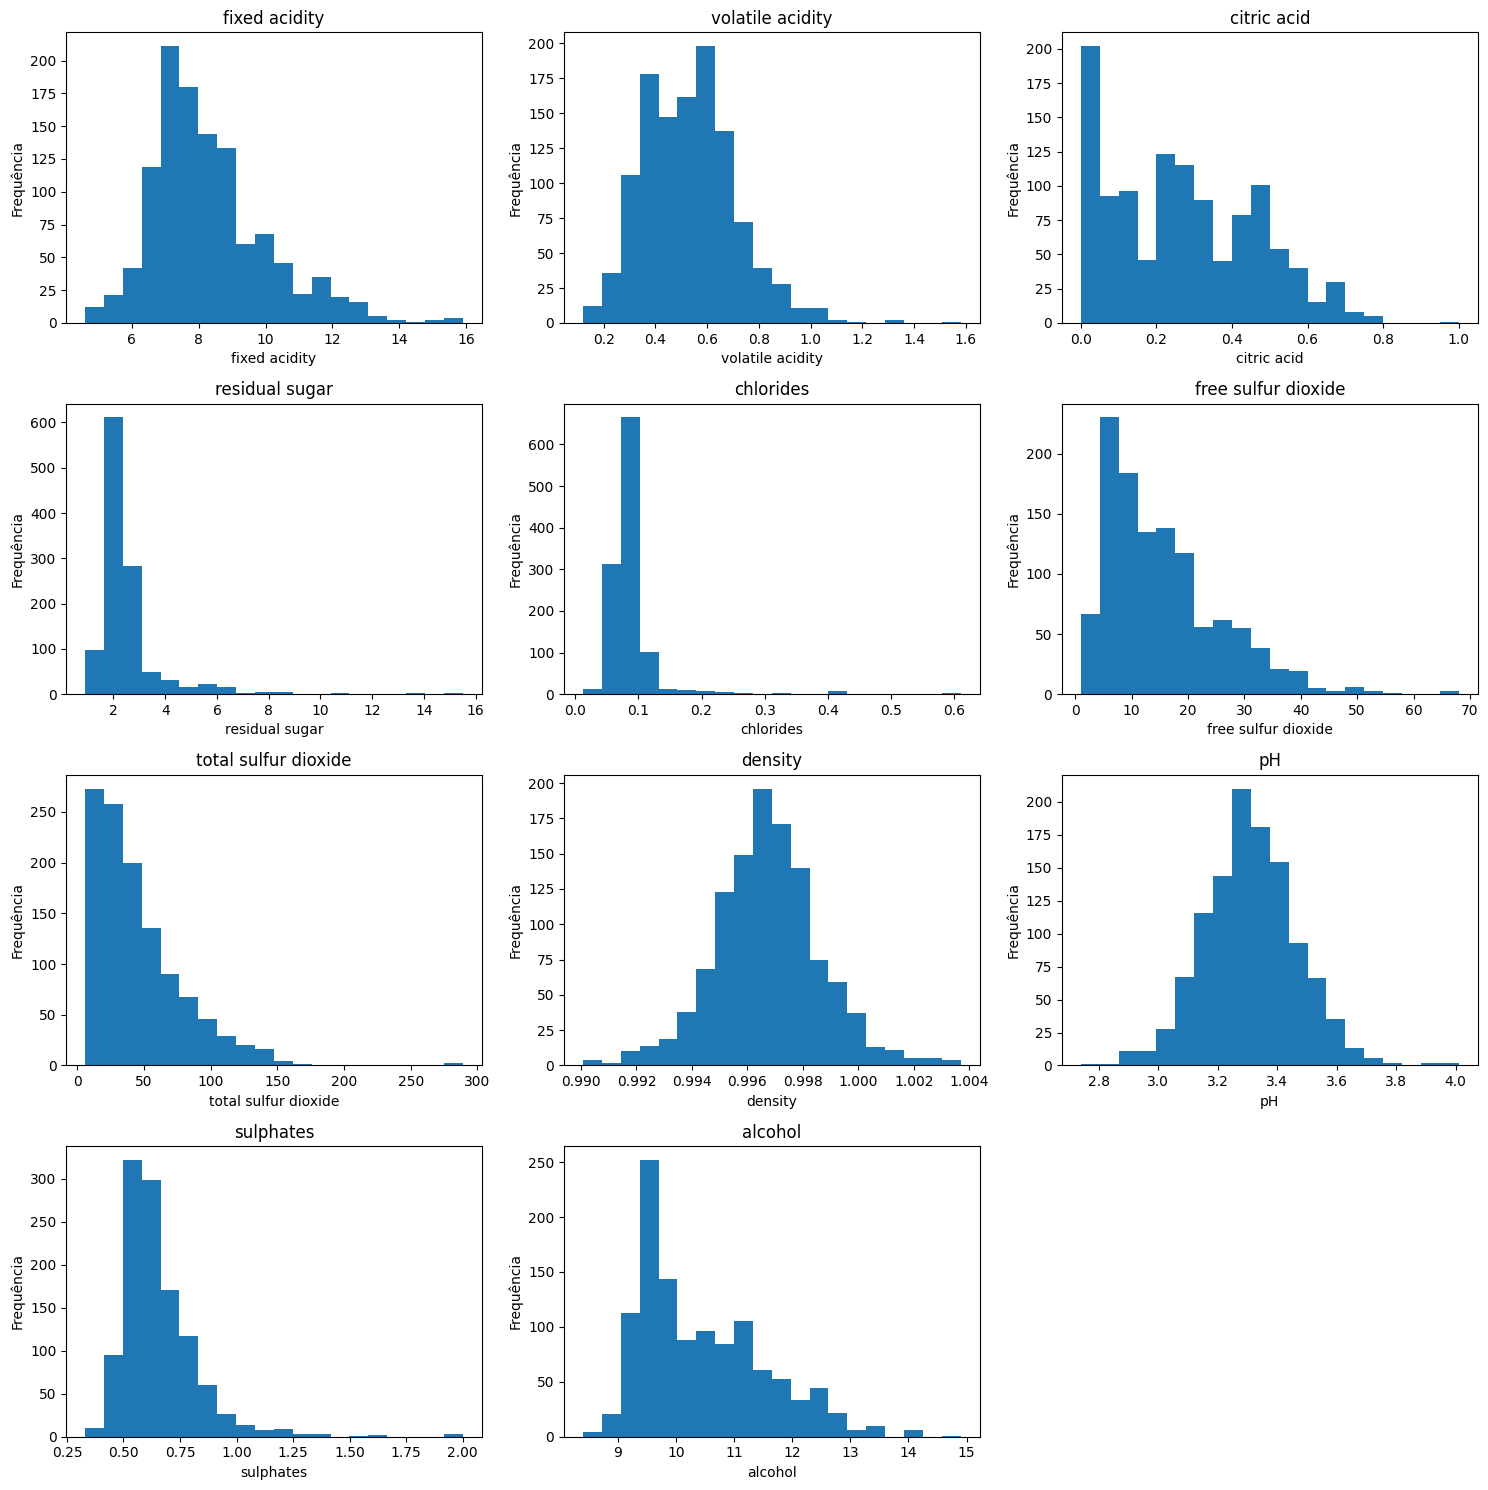

In [209]:
fig, axes = plt.subplots(4, 3, figsize=(15, 15))

axes = axes.flatten()

for indice, variavel in enumerate(variaveis_numericas):
  axes[indice].hist(dados[variavel], bins=20)
  axes[indice].set_title(variavel)
  axes[indice].set_xlabel(variavel)
  axes[indice].set_ylabel("Frequência")

axes[-1].set_visible(False)

plt.tight_layout()

plt.savefig(
    "results/EDA/distribuicao_variaveis.png",
    dpi=300,
    bbox_inches="tight"
    )

plt.show()

####Análise dos Histogramas

A análise dos histogramas permitiu identificar diferentes padrões de distribuição entre as variáveis físico-químicas. Observou-se que algumas variáveis, como density e pH, apresentam distribuição aproximadamente simétrica, indicando uma concentração mais equilibrada dos valores em torno da região central.

Por outro lado, variáveis como residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide e sulphates apresentam assimetria positiva (cauda à direita), sugerindo que a maioria das observações está concentrada em valores menores, enquanto um número reduzido de amostras apresenta valores significativamente mais elevados.

Além disso, algumas variáveis apresentam maior concentração dos dados em intervalos específicos, enquanto outras demonstram maior variabilidade. Os histogramas também sugerem a possível presença de valores extremos em algumas variáveis, hipótese que será investigada na etapa de identificação de outliers por meio dos boxplots.

De forma geral, esta análise permitiu compreender o comportamento inicial das variáveis, fornecendo informações importantes para as etapas seguintes de correlação, tratamento dos dados e construção dos modelos de Machine Learning.

##3.2 Correlação entre as Variáveis
Nesta seção serão investigadas as relações entre as variáveis do conjunto de dados, com o objetivo de identificar possíveis associações entre elas e verificar quais características apresentam maior relação com a variável alvo (quality_binary). A interpretação dessas correlações contribuirá para uma melhor compreensão do comportamento dos dados e do problema de classificação.


In [152]:
# Criando um novo DataFrame para a análise de correlação
dados_correlacao = dados.drop(columns=["Id","quality"])

In [153]:
# Calculando a matriz de correlação
correlacao = dados_correlacao.corr()

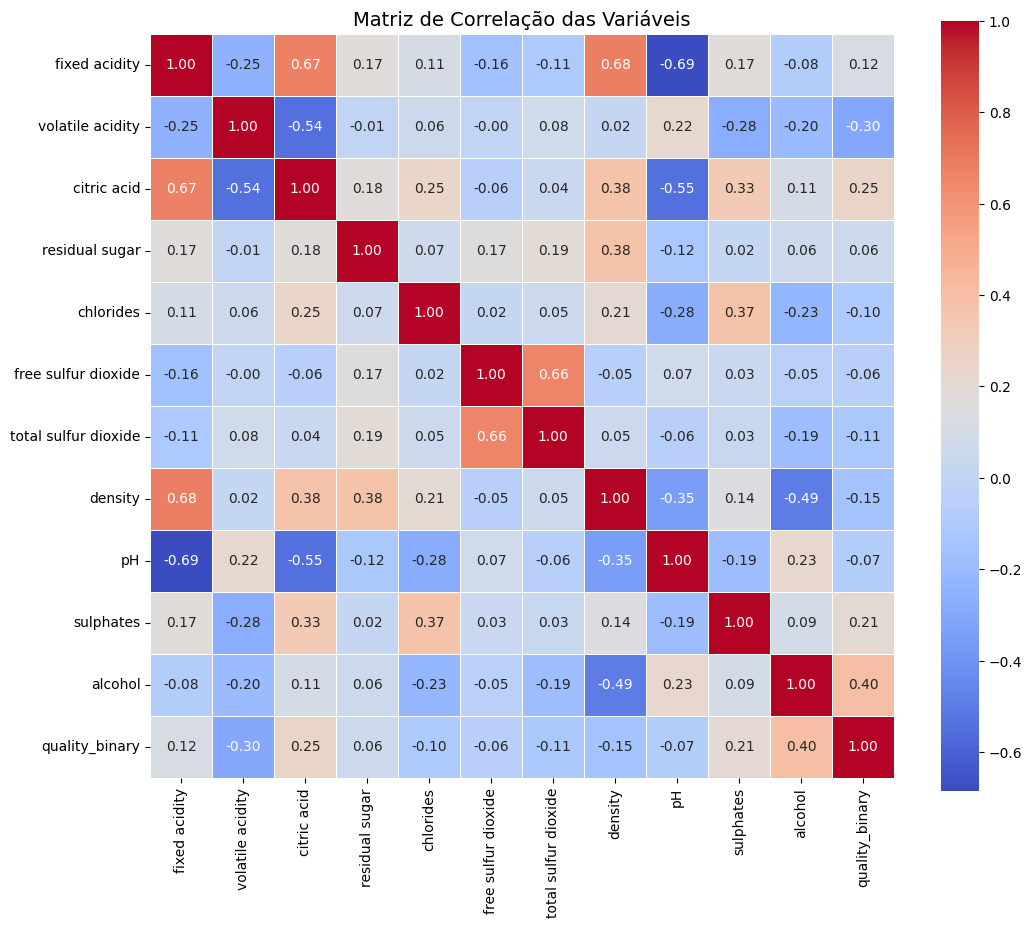

In [210]:
# Construindo Heatmap

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
)

plt.title("Matriz de Correlação das Variáveis", fontsize=14)

plt.savefig(
    "results/EDA/matriz_correlacao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


####Análise da Matriz de Correlação

A matriz de correlação permitiu identificar a intensidade e a direção das relações lineares entre as variáveis do conjunto de dados.

Em relação à variável alvo (quality_binary), observou-se que alcohol apresentou a maior correlação positiva (0,40), indicando que vinhos com maior teor alcoólico tendem a ser classificados como de maior qualidade. Por outro lado, volatile acidity apresentou a maior correlação negativa (-0,30), sugerindo que maiores níveis dessa variável estão associados a vinhos de menor qualidade. Além disso, citric acid e sulphates apresentaram correlações positivas de menor intensidade, indicando que também podem contribuir para a classificação da qualidade.

Entre as variáveis preditoras, destacam-se as correlações entre fixed acidity e pH (-0,69), fixed acidity e density (0,68), bem como entre free sulfur dioxide e total sulfur dioxide (0,66). Essas relações sugerem que algumas variáveis compartilham informações semelhantes, aspecto que deverá ser considerado durante a etapa de modelagem.

Por fim, ressalta-se que a correlação representa uma associação estatística entre as variáveis e não implica uma relação de causa e efeito.

##3.3 Identificação de Outliers
Nesta etapa será realizada a análise de possíveis valores extremos (outliers) presentes nas variáveis numéricas do conjunto de dados por meio de boxplots. O objetivo é identificar observações atípicas que possam influenciar o desempenho dos modelos de Machine Learning, avaliando se representam características naturais do conjunto de dados ou possíveis inconsistências que necessitem de tratamento antes da etapa de modelagem.

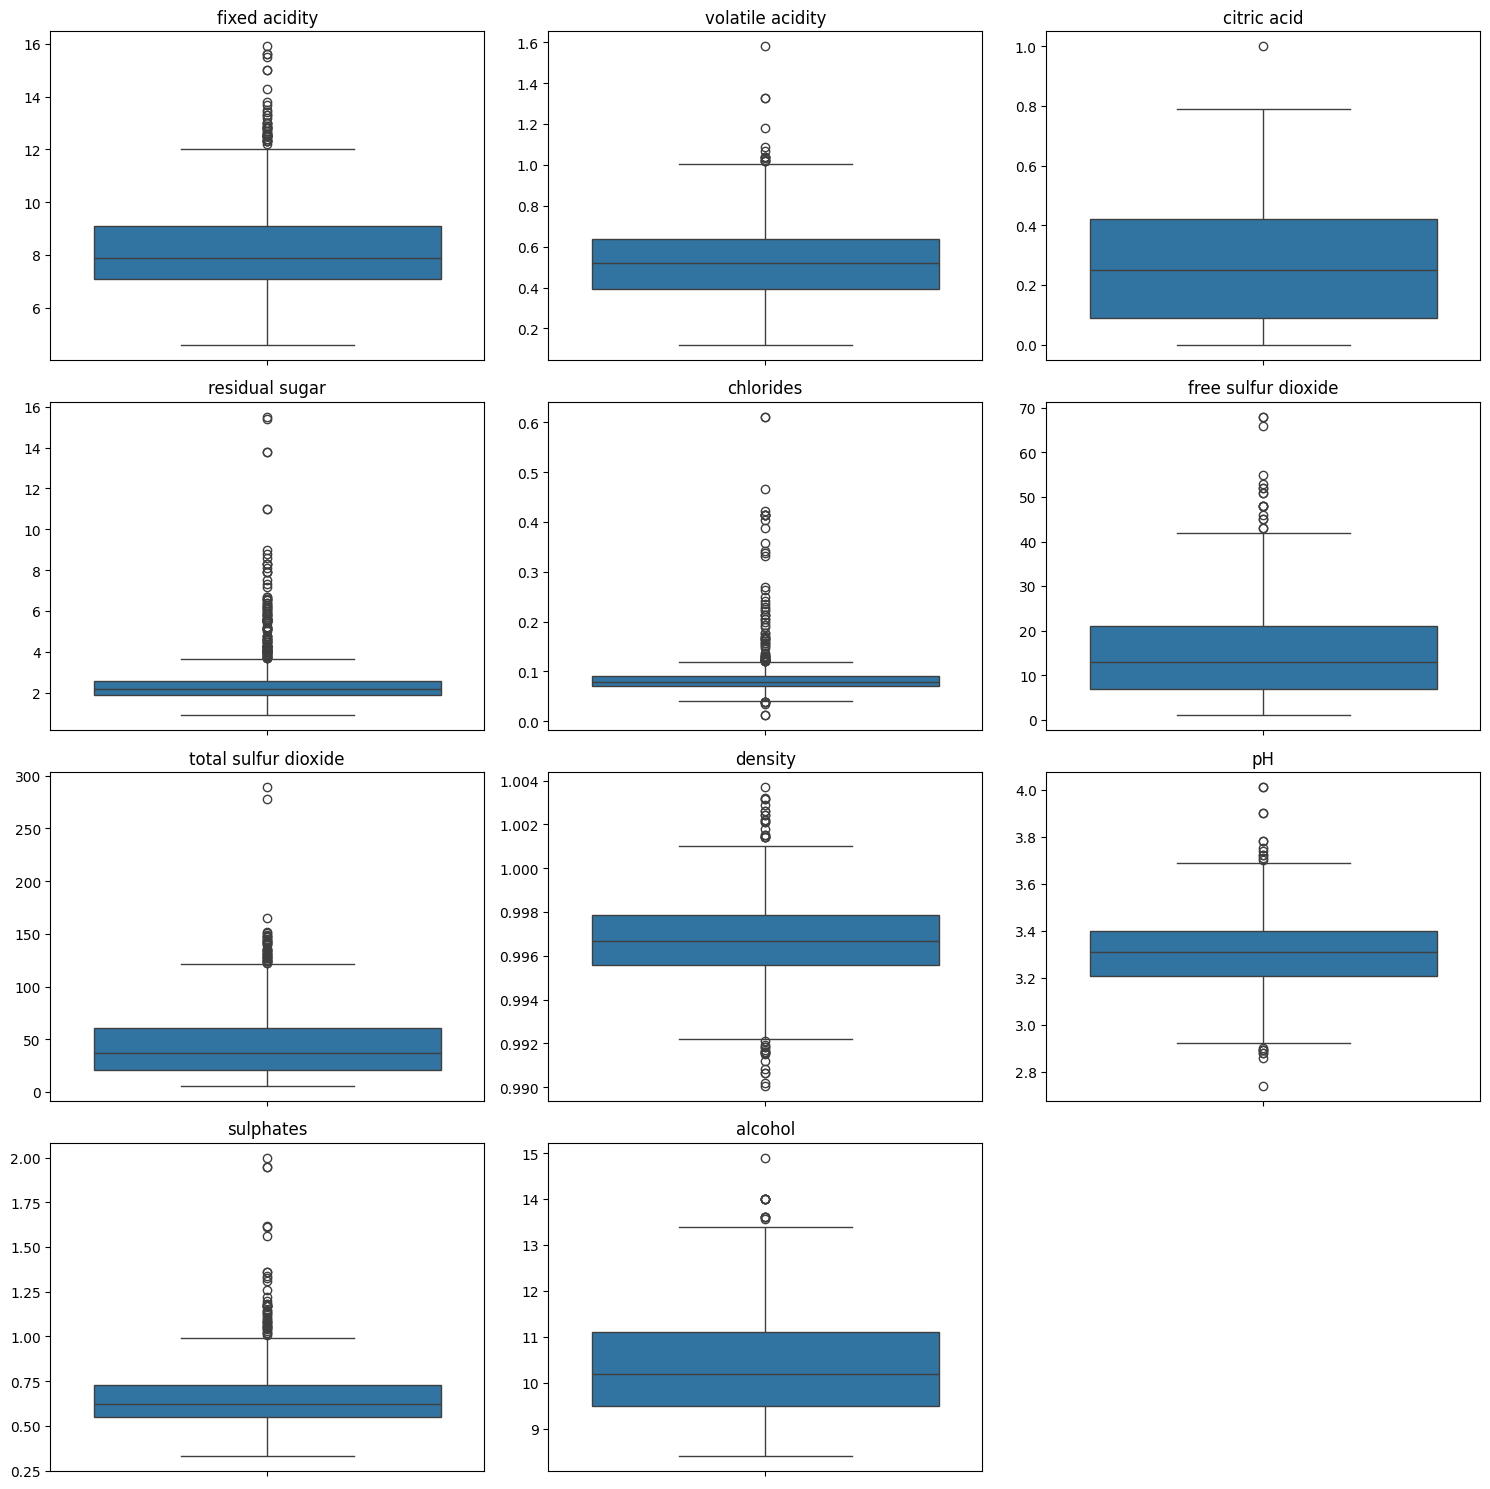

In [211]:
fig, axes = plt.subplots(4, 3, figsize=(15, 15))

axes = axes.flatten()

for indice, variavel in enumerate(variaveis_numericas):

  sns.boxplot(
      y=dados[variavel],
      ax=axes[indice]
  )

  axes[indice].set_title(variavel)
  axes[indice].set_ylabel("")
  axes[indice].set_xlabel("")

axes[-1].set_visible(False)

plt.tight_layout()

plt.savefig(
    "results/EDA/boxplots_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Análise dos Boxplots

A análise dos boxplots permitiu identificar a presença de possíveis outliers em grande parte das variáveis numéricas do conjunto de dados. Observa-se que algumas variáveis, como residual sugar, chlorides, total sulfur dioxide, fixed acidity e sulphates, apresentam uma quantidade mais expressiva de valores acima do limite superior do boxplot, enquanto outras apresentam apenas poucos valores extremos.

De maneira geral, os possíveis outliers não se concentram em uma única variável, mas estão distribuídos em diferentes características físico-químicas do conjunto de dados. Além disso, os valores observados permanecem dentro de faixas plausíveis para esse tipo de informação, não havendo evidências de erros de medição ou inconsistências nos dados.

Dessa forma, optou-se por não realizar o tratamento dos outliers nesta etapa, uma vez que esses valores podem representar características naturais da variabilidade do processo de produção dos vinhos. A remoção dessas observações poderia reduzir a capacidade dos modelos de Machine Learning de aprender adequadamente o comportamento real dos dados.

## 3.4 Análise do Balanceamento das Classes

Conforme observado na Seção 2.4, durante a criação da variável quality_binary, a distribuição das classes apresenta um desbalanceamento, com predominância da classe 0 (Baixa/Média Qualidade) em relação à classe 1 (Alta Qualidade). Essa característica será considerada nas etapas de modelagem e avaliação dos algoritmos de classificação.

# 4.Pré-processamento de Dados

Nesta etapa serão realizadas as transformações necessárias para preparar os dados para a construção dos modelos de Machine Learning. Serão verificados possíveis dados faltantes, avaliada a necessidade de normalização ou padronização das variáveis numéricas e analisada a possibilidade de criação de novas variáveis (feature engineering), caso seja considerada relevante para melhorar o desempenho dos modelos.

##4.1 Tratamento de Dados Faltantes

In [156]:
dados.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


A verificação confirmou que o conjunto de dados não apresenta valores faltantes em nenhuma das variáveis, não sendo necessário realizar qualquer tratamento relacionado à imputação ou remoção de observações nesta etapa.

##4.2 Normalização ou Padronização
Nesta etapa foi avaliada a necessidade de aplicar técnicas de Feature Scaling às variáveis numéricas do conjunto de dados.

Observou-se que as variáveis apresentam escalas diferentes, conforme identificado anteriormente na análise descritiva. Entretanto, a aplicação de normalização ou padronização depende do algoritmo de Machine Learning que será utilizado.

Neste projeto serão treinados três modelos de classificação: Logistic Regression, Decision Tree e Random Forest. A padronização será aplicada apenas ao modelo de Logistic Regression, uma vez que esse algoritmo é sensível às diferenças de escala entre as variáveis. Para os modelos Decision Tree e Random Forest, essa etapa não será necessária, pois esses algoritmos realizam divisões baseadas em limiares (thresholds) e não em cálculos de distância.

Além disso, considerando a presença de possíveis outliers identificados durante a Análise Exploratória dos Dados (EDA), optou-se pela utilização do StandardScaler em vez do MinMaxScaler, por ser uma abordagem mais adequada para esse contexto.

A padronização será realizada posteriormente, após a divisão dos dados em conjuntos de treinamento e teste, evitando o vazamento de informações (data leakage) entre os conjuntos de dados.

##4.3 Feature Engineering
Foi avaliada a necessidade de criação de novas variáveis (Feature Engineering). Entretanto, considerando que o conjunto de dados já contém um conjunto abrangente de características físico-químicas dos vinhos e que não foi identificada nenhuma combinação de variáveis com justificativa técnica ou científica para representar melhor o problema, optou-se por não criar novas features nesta etapa.

Dessa forma, serão utilizadas as variáveis originais do conjunto de dados para o treinamento dos modelos de Machine Learning.

#5.Desenvolvimento dos Modelos
Nesta etapa serão desenvolvidos e avaliados os modelos de classificação propostos para o problema. Inicialmente, será definido o conjunto de variáveis preditoras e a variável alvo, seguido pela divisão dos dados em conjuntos de treinamento e teste. Em seguida, serão aplicadas as etapas de pré-processamento necessárias para cada algoritmo, respeitando suas características específicas.

##5.1 Definição das Variáveis Preditoras e Variável Alvo
Nesta etapa serão definidas as variáveis preditoras (X) e a variável alvo (y), que serão utilizadas no treinamento dos modelos de classificação.

As variáveis preditoras correspondem às características físico-químicas dos vinhos, enquanto a variável alvo (**quality_binary**) representa a classificação do vinho em duas categorias: Baixa/Média Qualidade (0) e Alta Qualidade (1).

A variável **quality** será excluída da modelagem, pois foi utilizada apenas para a criação da variável alvo binária

*   Elemento de lista
*   Elemento de lista

(**quality_binary**). Da mesma forma, a variável **Id** também será removida por representar apenas um identificador das amostras, sem significado preditivo para o modelo.

In [157]:
X = dados.drop(columns=["Id", "quality", "quality_binary"])

y = dados["quality_binary"]

In [158]:
print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (1143, 11)
Dimensão de y: (1143,)



As variáveis preditoras (X) e a variável alvo (y) foram definidas corretamente para o treinamento dos modelos de classificação. O conjunto de dados utilizado na modelagem é composto por 11 variáveis preditoras e uma variável alvo binária, representando a qualidade do vinho.

##5.2 Divisão dos Dados
Nesta etapa, o conjunto de dados será dividido em dois subconjuntos: treinamento e teste. O conjunto de treinamento será utilizado para o aprendizado dos modelos de Machine Learning, enquanto o conjunto de teste será reservado para avaliar a capacidade de generalização dos modelos em dados não utilizados durante o treinamento.

Foi adotada uma divisão de **80% para treinamento** e **20% para teste**, proporção amplamente utilizada em problemas de classificação, permitindo um equilíbrio entre aprendizado e avaliação.

Além disso, será utilizado o parâmetro **stratify=y**, preservando a proporção das classes nos dois subconjuntos, uma vez que a variável alvo apresenta desbalanceamento entre as categorias. Também será definido **random_state=1992**, garantindo a reprodutibilidade da divisão dos dados em diferentes execuções do notebook.

In [159]:
from sklearn.model_selection import train_test_split


In [160]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1992, stratify=y)


In [161]:
print("Dimensão de X_train:", X_train.shape)
print("Dimensão de X_test:", X_test.shape)
print("Dimensão de y_train:", y_train.shape)
print("Dimensão de y_test:", y_test.shape)

Dimensão de X_train: (914, 11)
Dimensão de X_test: (229, 11)
Dimensão de y_train: (914,)
Dimensão de y_test: (229,)


In [162]:
print("Distribuição em y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribuição em y_test:")
print(y_test.value_counts(normalize=True))

Distribuição em y_train:
quality_binary
0    0.86105
1    0.13895
Name: proportion, dtype: float64

Distribuição em y_test:
quality_binary
0    0.860262
1    0.139738
Name: proportion, dtype: float64


#### Análise

O conjunto de dados foi dividido corretamente em treinamento (80%) e teste (20%), resultando em 914 observações para treinamento e 229 observações para teste.

Além disso, a utilização do parâmetro **stratify=y** preservou a distribuição das classes da variável alvo nos dois subconjuntos. Observa-se que aproximadamente 86% das observações pertencem à classe 0 e 14% à classe 1, tanto no conjunto de treinamento quanto no conjunto de teste, garantindo que ambos representem adequadamente a distribuição original dos dados.

##5.3 Pipeline 1 – Logistic Regression (Baseline)
Nesta etapa será desenvolvido o primeiro modelo de classificação, utilizando a **Logistic Regression** como modelo baseline. Antes do treinamento, será realizado o pré-processamento necessário para esse algoritmo, incluindo a padronização das variáveis numéricas e o balanceamento das classes no conjunto de treinamento. Em seguida, o modelo será treinado e avaliado por meio das métricas de desempenho definidas para este estudo.

In [163]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

In [164]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [165]:
pd.DataFrame(X_train_scaled, columns=X_train.columns).head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.086582,-1.592889,0.338280,1.861087,-0.544108,-0.751692,-0.735790,0.317350,-0.575830,1.646971,0.433777
1,-1.398854,0.621471,-0.783999,-0.406568,-0.263164,1.550453,-0.075538,-0.672048,1.664871,0.293838,-0.214028
2,0.997469,-1.210160,0.389293,-0.699168,-0.263164,-0.655769,-0.555721,-0.031246,-0.447790,0.999820,0.711407
3,0.883358,-0.007298,1.511571,-0.113967,0.125836,1.358607,0.164554,0.163557,-0.767890,0.587997,1.081581
4,-1.056522,1.933684,-1.396151,-0.187117,1.703448,-0.943537,-1.035905,-0.651542,1.600851,-0.882800,0.341233


In [166]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [167]:
X_train_scaled.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.086582,-1.592889,0.338280,1.861087,-0.544108,-0.751692,-0.735790,0.317350,-0.575830,1.646971,0.433777
1,-1.398854,0.621471,-0.783999,-0.406568,-0.263164,1.550453,-0.075538,-0.672048,1.664871,0.293838,-0.214028
2,0.997469,-1.210160,0.389293,-0.699168,-0.263164,-0.655769,-0.555721,-0.031246,-0.447790,0.999820,0.711407
3,0.883358,-0.007298,1.511571,-0.113967,0.125836,1.358607,0.164554,0.163557,-0.767890,0.587997,1.081581
4,-1.056522,1.933684,-1.396151,-0.187117,1.703448,-0.943537,-1.035905,-0.651542,1.600851,-0.882800,0.341233


In [168]:
X_train_scaled.describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,914.00,914.00,914.00,914.00,914.00,914.00,914.00,914.00,914.00,914.00,914.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.14,-2.25,-1.40,-1.21,-1.62,-1.42,-1.22,-3.44,-3.65,-1.94,-1.88
25%,-0.71,-0.77,-0.89,-0.48,-0.37,-0.85,-0.77,-0.61,-0.70,-0.65,-0.86
50%,-0.20,-0.06,-0.07,-0.26,-0.18,-0.27,-0.26,-0.03,0.00,-0.24,-0.21
75%,0.48,0.59,0.78,0.03,0.06,0.59,0.46,0.56,0.58,0.41,0.62
max,4.31,5.73,3.71,9.40,11.30,5.00,7.28,3.54,4.48,7.88,4.14


#### Análise

A padronização das variáveis foi realizada com sucesso utilizando o **StandardScaler**. Após a transformação, observa-se que todas as variáveis apresentam média aproximadamente igual a zero e desvio padrão igual a um, conforme esperado para esse método.

Essa etapa elimina as diferenças de escala entre as variáveis numéricas, permitindo que algoritmos sensíveis à magnitude dos atributos, como a **Logistic Regression**, sejam treinados de forma mais adequada.

Com a padronização concluída, o conjunto de treinamento está preparado para as próximas etapas do pipeline da Logistic Regression. A seguir, será realizado o balanceamento das classes utilizando a técnica **SMOTE**, aplicada exclusivamente ao conjunto de treinamento.

#### Balanceamento das Classes (SMOTE)

Como identificado durante a Análise Exploratória dos Dados (EDA), a variável alvo apresenta desbalanceamento entre as classes, com predominância da classe **0 (Baixa/Média Qualidade)** em relação à classe **1 (Alta Qualidade)**.

Para minimizar esse desequilíbrio durante o treinamento, será utilizada a técnica **SMOTE (Synthetic Minority Over-sampling Technique)**, que gera novas amostras sintéticas da classe minoritária com base nas observações existentes. O balanceamento será aplicado **exclusivamente ao conjunto de treinamento**, preservando o conjunto de teste com sua distribuição original para garantir uma avaliação mais realista do desempenho dos modelos.

In [169]:
smote = SMOTE(random_state=1992)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

In [170]:
print(y_train.value_counts())

print("\nDepois do SMOTE:\n")

print(y_train_balanced.value_counts())

quality_binary
0    787
1    127
Name: count, dtype: int64

Depois do SMOTE:

quality_binary
0    787
1    787
Name: count, dtype: int64


#### Análise

A aplicação da técnica **SMOTE** foi realizada com sucesso sobre o conjunto de treinamento. Após o balanceamento, observa-se que as duas classes passaram a apresentar a mesma quantidade de observações, eliminando o desbalanceamento identificado durante a etapa de Análise Exploratória dos Dados (EDA).

Esse procedimento permite que o modelo tenha a mesma oportunidade de aprender os padrões das duas classes, reduzindo a tendência de favorecer a classe majoritária durante o treinamento.

Com a aplicação do **SMOTE**, o conjunto de treinamento encontra-se balanceado e preparado para o treinamento da **Logistic Regression**. Ressalta-se que o balanceamento foi realizado exclusivamente sobre os dados de treinamento, mantendo o conjunto de teste inalterado para garantir uma avaliação imparcial do desempenho do modelo.

In [171]:
modelo_lr = LogisticRegression(random_state=1992)

In [172]:
modelo_lr.fit(X_train_balanced, y_train_balanced)

LogisticRegression(random_state=1992)

In [173]:
y_pred_lr = modelo_lr.predict(X_test_scaled)

In [174]:
y_prob_lr = modelo_lr.predict_proba(X_test_scaled)[:,1]

###5.3.1 Avaliação da Logistic Regression

Após o treinamento da Logistic Regression, o desempenho do modelo será avaliado utilizando diferentes métricas de classificação. Serão analisadas métricas como Accuracy, Precision, Recall, F1-score, Matriz de Confusão e ROC AUC, permitindo uma avaliação mais completa da capacidade preditiva do modelo.

In [175]:
from sklearn.metrics import accuracy_score

In [176]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f"Acurácia: {accuracy_lr:.4f}")

Acurácia: 0.7817


#### Análise

A Logistic Regression obteve uma acurácia de **78,17%**, indicando que aproximadamente 78% das observações do conjunto de teste foram classificadas corretamente.

Entretanto, como o problema apresenta desbalanceamento entre as classes, a acurácia isoladamente não é suficiente para avaliar o desempenho do modelo. Dessa forma, torna-se necessário analisar métricas adicionais, como Precision, Recall, F1-score e a Matriz de Confusão, para compreender o comportamento do modelo em relação às duas classes.

In [177]:
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score)

In [178]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(y_test, y_pred_lr)

recall_lr = recall_score(y_test, y_pred_lr)

f1_lr = f1_score(y_test, y_pred_lr)

auc_lr = roc_auc_score(y_test, y_prob_lr)

In [179]:
print(f"Acurácia: {accuracy_lr:.4f}")
print(f"Precisão : {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")
print(f"ROC AUC  : {auc_lr:.4f}")

Acurácia: 0.7817
Precisão : 0.3548
Recall   : 0.6875
F1-score : 0.4681
ROC AUC  : 0.8393


In [180]:
print("\nRelatório de Classificação:\n")

print(classification_report(y_test, y_pred_lr))


Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.94      0.80      0.86       197
           1       0.35      0.69      0.47        32

    accuracy                           0.78       229
   macro avg       0.65      0.74      0.67       229
weighted avg       0.86      0.78      0.81       229



A Logistic Regression apresentou acurácia de 78,17% e ROC AUC de 0,8393, indicando boa capacidade geral de discriminação entre as classes. No entanto, para a classe 1 (Alta Qualidade), observou-se precisão de 35,48% e recall de 68,75%. Isso indica que o modelo consegue identificar uma parcela relevante dos vinhos de alta qualidade, mas ainda gera um número considerável de falsos positivos. Dessa forma, o modelo baseline apresenta desempenho inicial razoável, servindo como referência para comparação com modelos mais complexos.

### Matriz de Confusão

A Matriz de Confusão permite analisar detalhadamente o desempenho do modelo, comparando as classes reais com as classes preditas. A partir dela é possível identificar os acertos e erros de classificação, sendo a base para o cálculo de métricas como Accuracy, Precision, Recall e F1-score.

In [181]:
from sklearn.metrics import ConfusionMatrixDisplay

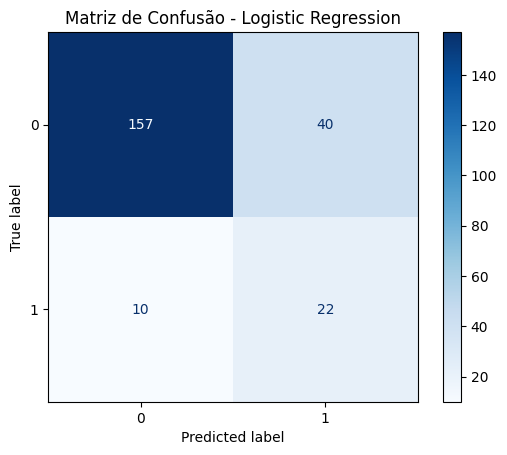

In [212]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap="Blues")

plt.title("Matriz de Confusão - Logistic Regression")

plt.savefig(
    "results/ML/matriz_confusao_logistic_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Análise

A Matriz de Confusão mostra que o modelo classificou corretamente **157 observações da classe 0 (Verdadeiros Negativos)** e **22 observações da classe 1 (Verdadeiros Positivos)**.

Entretanto, foram observados **40 Falsos Positivos**, indicando que parte das amostras pertencentes à classe 0 foi incorretamente classificada como classe 1. Além disso, ocorreram **10 Falsos Negativos**, correspondendo às amostras da classe 1 que não foram identificadas pelo modelo.

Esses resultados mostram que a Logistic Regression apresentou boa capacidade para identificar a classe positiva, porém ao custo de um número relativamente elevado de Falsos Positivos.

A análise da Matriz de Confusão confirma os resultados observados nas métricas de avaliação. O modelo apresentou um **Recall relativamente elevado**, conseguindo identificar a maior parte das observações da classe positiva. Entretanto, a quantidade de **Falsos Positivos** contribuiu para uma redução da Precision.

Esses resultados indicam que a Logistic Regression constitui um modelo baseline adequado para este problema, servindo como referência para comparação com algoritmos mais robustos, como Decision Tree e Random Forest.

### Curva ROC

A Curva ROC (Receiver Operating Characteristic) avalia a capacidade do modelo em distinguir as classes para diferentes valores de limiar (threshold). Diferentemente das métricas obtidas para um único threshold, a Curva ROC analisa o comportamento do classificador considerando todos os limiares possíveis.

A área sob a curva (ROC AUC) resume esse desempenho em um único valor, variando entre 0 e 1. Quanto mais próximo de 1, melhor a capacidade do modelo em separar corretamente as classes.

In [183]:
from sklearn.metrics import RocCurveDisplay

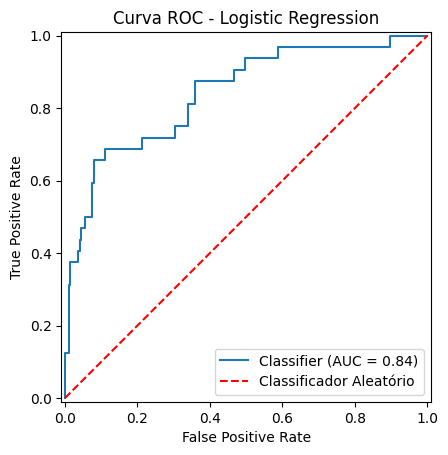

In [213]:
RocCurveDisplay.from_predictions(y_test, y_prob_lr)

plt.plot([0,1], [0,1], linestyle="--", color="red", label="Classificador Aleatório")

plt.title("Curva ROC - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.savefig(
    "results/ML/curva_roc_logistic_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Análise

A Curva ROC demonstra que a Logistic Regression apresenta boa capacidade de discriminar as duas classes ao longo de diferentes valores de threshold. Observa-se que a curva permanece significativamente acima da linha de referência aleatória, indicando desempenho superior ao acaso.

O valor de **ROC AUC = 0,8393** confirma que o modelo possui boa capacidade de separação entre as classes, mesmo apresentando limitações observadas na Precision devido ao elevado número de Falsos Positivos.

A análise da Curva ROC confirma que a Logistic Regression constitui um modelo baseline consistente para este problema de classificação. Apesar da Precision relativamente baixa, o modelo apresenta boa capacidade discriminatória, evidenciada pelo valor de ROC AUC superior a 0,80. Esses resultados servirão como referência para comparação com os modelos Decision Tree e Random Forest nas próximas etapas do estudo.

##5.4 Pipeline 2 – Decision Tree

A Árvore de Decisão será utilizada como segundo modelo de classificação. Diferentemente da Logistic Regression, este algoritmo não depende da escala das variáveis, dispensando a etapa de padronização dos dados.

Entretanto, como o conjunto de treinamento permanece desbalanceado, será mantida a aplicação do SMOTE para equilibrar as classes antes do treinamento do modelo.

In [185]:
from sklearn.tree import DecisionTreeClassifier

In [186]:
smote = SMOTE(random_state=1992)

X_train_balanced_dt, y_train_balanced_dt = smote.fit_resample(X_train, y_train)

In [187]:
modelo_dt = DecisionTreeClassifier(random_state=1992)

modelo_dt.fit(X_train_balanced_dt, y_train_balanced_dt)

DecisionTreeClassifier(random_state=1992)

In [188]:
y_pred_dt = modelo_dt.predict(X_test)

In [189]:
y_prob_dt = modelo_dt.predict_proba(X_test)[:,1]

In [190]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print(f"ROC AUC: {roc_auc_dt:.4f}")

Decision Tree
Accuracy: 0.8646
Precision: 0.5111
Recall: 0.7188
F1-score: 0.5974
ROC AUC: 0.8035


In [191]:
print("Classification Report - Decision Tree")
print(classification_report(y_test, y_pred_dt))

Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       197
           1       0.51      0.72      0.60        32

    accuracy                           0.86       229
   macro avg       0.73      0.80      0.76       229
weighted avg       0.89      0.86      0.87       229



#### Análise

O Classification Report fornece uma visão detalhada do desempenho do modelo para cada classe individualmente.

Observa-se que o modelo apresentou excelente desempenho na classificação da classe **0**, alcançando valores elevados de Precision, Recall e F1-score. Isso indica que a maioria dos vinhos pertencentes à classe majoritária foi corretamente identificada.

Para a classe **1**, considerada a classe minoritária, o modelo obteve um Recall de aproximadamente 72%, demonstrando boa capacidade para identificar a maior parte dos casos positivos. Entretanto, a Precision foi de aproximadamente 51%, indicando a presença de falsos positivos quando o modelo prevê essa classe.

Além disso, como o conjunto de dados apresenta desbalanceamento entre as classes (197 observações da classe 0 e 32 da classe 1), os indicadores **Macro Average** e **Weighted Average** devem ser interpretados em conjunto. O Macro Average atribui o mesmo peso para ambas as classes, permitindo avaliar o desempenho do modelo de forma mais equilibrada, enquanto o Weighted Average considera a proporção de observações de cada classe, refletindo o desempenho global do modelo.

De maneira geral, o Decision Tree apresentou um desempenho consistente, especialmente na identificação da classe positiva, superando os resultados obtidos anteriormente pela Regressão Logística em diversas métricas de avaliação.

## Matriz de Confusão

A matriz de confusão permite analisar detalhadamente o desempenho do modelo, comparando as classes reais com as classes previstas.

Essa visualização facilita a identificação dos verdadeiros positivos (TP), verdadeiros negativos (TN), falsos positivos (FP) e falsos negativos (FN), possibilitando compreender de onde são calculadas métricas como Accuracy, Precision e Recall.

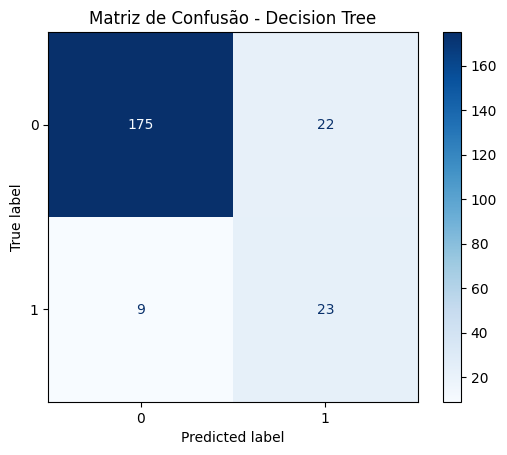

In [214]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, cmap="Blues")

plt.title("Matriz de Confusão - Decision Tree")

plt.savefig(
    "results/ML/matriz_confusao_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Análise

A matriz de confusão mostra que o modelo classificou corretamente **175 observações da classe 0 (Verdadeiros Negativos)** e **23 observações da classe 1 (Verdadeiros Positivos)**.

Além disso, foram observados **22 Falsos Positivos**, indicando casos em que vinhos da classe 0 foram classificados incorretamente como pertencentes à classe 1, e **9 Falsos Negativos**, correspondentes a vinhos da classe 1 que não foram identificados pelo modelo.

Comparando com a Regressão Logística, o Decision Tree apresentou uma redução tanto dos Falsos Positivos quanto dos Falsos Negativos, além de aumentar o número de classificações corretas para ambas as classes. Esses resultados são consistentes com a melhora observada nas métricas de Accuracy, Precision, Recall e F1-score, indicando um desempenho mais equilibrado do modelo.

## Curva ROC

A curva ROC (Receiver Operating Characteristic) avalia a capacidade do modelo em distinguir as classes ao longo de diferentes valores de threshold.

Diferentemente das métricas Accuracy, Precision, Recall e F1-score, que são calculadas utilizando um threshold fixo (0,5), a curva ROC considera todos os possíveis limiares de decisão.

A métrica ROC AUC (Area Under the Curve) representa a capacidade geral do modelo em separar corretamente as duas classes. Quanto mais próximo de 1, melhor o desempenho do classificador.

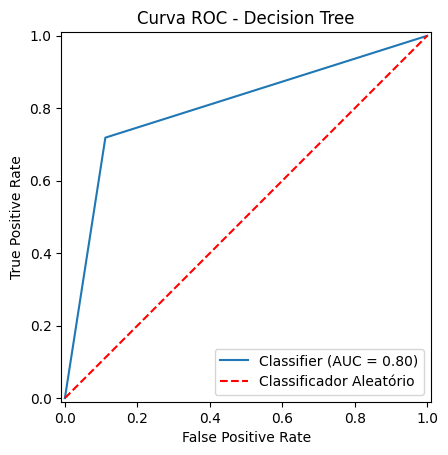

In [215]:
RocCurveDisplay.from_predictions(y_test, y_prob_dt)

plt.plot([0,1], [0,1], linestyle="--", color="red", label="Classificador Aleatório")
plt.title("Curva ROC - Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.savefig(
    "results/ML/curva_roc_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Análise

A curva ROC mostra que o modelo apresenta boa capacidade de discriminação entre as classes, permanecendo acima da linha de referência do classificador aleatório durante praticamente toda a curva.

O valor de **ROC AUC = 0,8035** indica que o Decision Tree possui boa capacidade para separar corretamente as observações das classes positiva e negativa considerando todos os possíveis valores de threshold.

Comparando com a Regressão Logística, observa-se que o Decision Tree apresentou um valor de ROC AUC ligeiramente inferior (0,8035 contra 0,8393). Entretanto, esse resultado não contradiz as demais métricas, pois o ROC AUC avalia a capacidade geral de discriminação do modelo em diferentes limiares de decisão, enquanto Accuracy, Precision, Recall e F1-score são calculados utilizando um threshold fixo.

De forma geral, o Decision Tree apresentou melhor desempenho nas métricas de classificação, enquanto a Regressão Logística demonstrou uma capacidade ligeiramente superior de separação das classes ao longo de todos os thresholds.

## Visualização da Árvore de Decisão

Uma das principais vantagens do algoritmo Decision Tree é sua interpretabilidade.

Ao contrário de outros modelos de Machine Learning, é possível visualizar a estrutura da árvore e compreender como o modelo toma suas decisões, observando quais variáveis são utilizadas em cada divisão e quais critérios levam à classificação final.

Como árvores muito profundas podem se tornar difíceis de interpretar, será apresentada apenas uma parte da estrutura utilizando uma profundidade limitada para facilitar a visualização.

In [194]:
from sklearn.tree import plot_tree

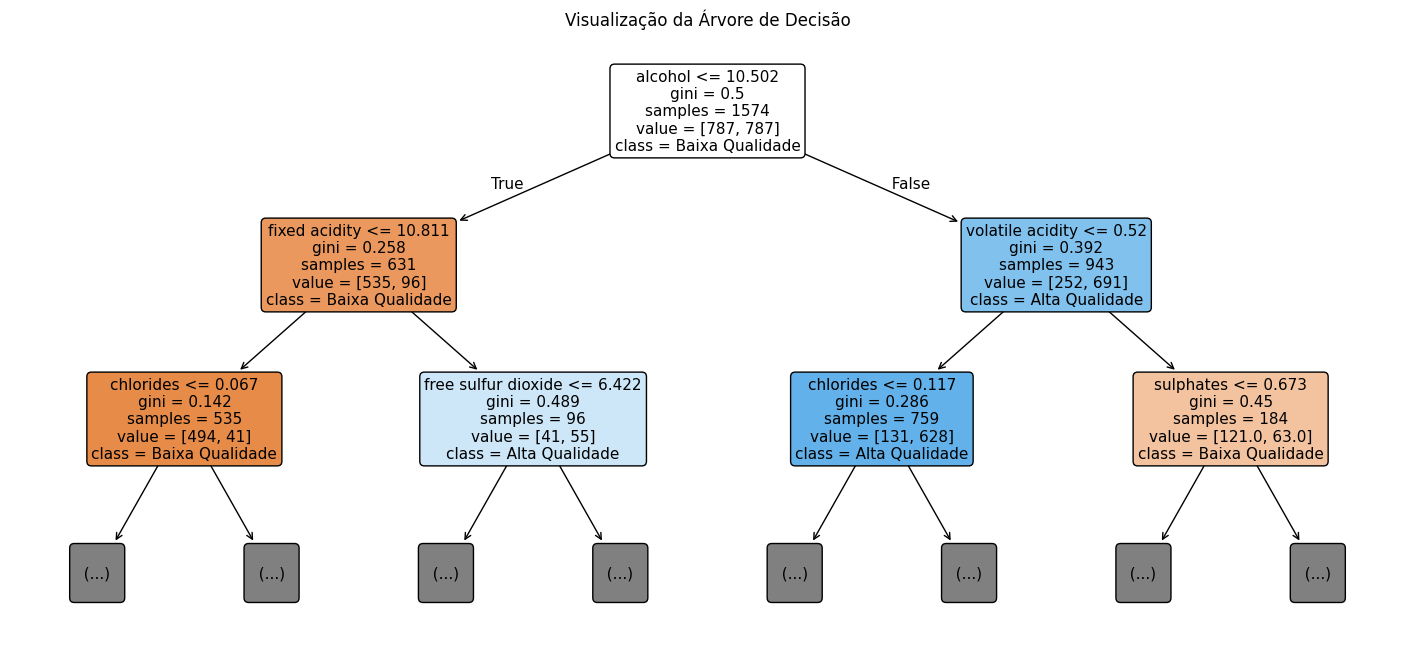

In [216]:
plt.figure(figsize=(18,8))

plot_tree(
    modelo_dt,
    feature_names=X.columns,
    class_names=["Baixa Qualidade", "Alta Qualidade"],
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=11
)

plt.title("Visualização da Árvore de Decisão")

plt.savefig(
    "results/ML/arvore_decisao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Análise

A visualização da árvore de decisão permitiu compreender de forma intuitiva como o modelo realiza o processo de classificação.

Observa-se que a primeira divisão foi realizada utilizando a variável **Alcohol**, indicando que este foi o atributo considerado mais relevante para reduzir a impureza dos dados. Em seguida, outras variáveis, como **Fixed Acidity**, **Volatile Acidity**, **Chlorides**, **Sulphates** e **Free Sulfur Dioxide**, foram utilizadas para refinar as decisões em diferentes ramos da árvore.

Cada nó apresenta informações importantes, como o índice **Gini**, que representa o grau de impureza do nó, o número de amostras (**Samples**) presentes naquele ponto da árvore, a distribuição das classes (**Value**) e a classe predominante (**Class**), que corresponde à classificação atribuída pelo modelo.

Como a árvore completa possui muitas ramificações, a visualização foi limitada aos primeiros níveis utilizando o parâmetro **max_depth**, permitindo uma interpretação mais clara das principais regras aprendidas pelo algoritmo.

A visualização da árvore confirmou que o modelo Decision Tree toma suas decisões de forma sequencial, utilizando regras baseadas nos atributos do conjunto de dados.

Além de apresentar um bom desempenho nas métricas de classificação, o modelo possui uma importante vantagem em relação a outros algoritmos: sua elevada interpretabilidade. Isso permite compreender quais variáveis exercem maior influência na classificação e como cada decisão é construída ao longo da árvore.

Embora árvores muito profundas possam se tornar difíceis de interpretar, a limitação da profundidade da visualização possibilitou identificar as principais regras de decisão aprendidas pelo modelo, agregando valor à análise realizada neste estudo.

##5.5 Pipeline 3 – Random Forest

O Random Forest é um algoritmo de aprendizado supervisionado baseado na combinação de múltiplas Árvores de Decisão.

Enquanto o Decision Tree utiliza apenas uma única árvore para realizar a classificação, o Random Forest constrói diversas árvores utilizando diferentes amostras do conjunto de treinamento e subconjuntos aleatórios de atributos.

A previsão final é obtida por meio da votação da maioria entre todas as árvores, tornando o modelo mais robusto, reduzindo o risco de overfitting e melhorando sua capacidade de generalização.

Assim como o Decision Tree, o Random Forest não necessita de padronização das variáveis, pois seu processo de decisão é baseado em regras de divisão e não em cálculos de distância entre os dados.

Nesta etapa será desenvolvido o modelo Random Forest e seu desempenho será comparado com os modelos Logistic Regression e Decision Tree.

In [196]:
from sklearn .ensemble import RandomForestClassifier

In [197]:
modelo_rf = RandomForestClassifier(random_state=1992)

In [198]:
modelo_rf.fit(X_train_balanced_dt, y_train_balanced_dt)

RandomForestClassifier(random_state=1992)

In [199]:
y_pred_rf = modelo_rf.predict(X_test)

In [200]:
y_prob_rf = modelo_rf.predict_proba(X_test)[:,1]

In [201]:
# Avaliação do modelo Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print(f"ROC AUC: {roc_auc_rf:.4f}")

Random Forest
Accuracy: 0.8777
Precision: 0.5476
Recall: 0.7188
F1-score: 0.6216
ROC AUC: 0.8928


In [202]:
print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf))

Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.95      0.90      0.93       197
           1       0.55      0.72      0.62        32

    accuracy                           0.88       229
   macro avg       0.75      0.81      0.77       229
weighted avg       0.90      0.88      0.88       229



### Análise

O Classification Report mostra que o modelo Random Forest apresentou um excelente desempenho na classificação da classe **0**, alcançando valores elevados de Precision, Recall e F1-score, demonstrando alta capacidade para identificar corretamente os vinhos pertencentes à classe majoritária.

Para a classe **1**, correspondente aos vinhos de alta qualidade, o modelo obteve uma **Precision de aproximadamente 55%**, indicando que mais da metade das previsões positivas estavam corretas. O **Recall de aproximadamente 72%** demonstra que o modelo conseguiu identificar a maior parte dos vinhos realmente pertencentes à classe positiva.

Comparando com o Decision Tree, observa-se uma melhora na Precision e no F1-score da classe positiva, enquanto o Recall permaneceu praticamente inalterado. Esses resultados indicam que o Random Forest reduziu a quantidade de falsos positivos sem comprometer sua capacidade de identificar os casos positivos.

Além disso, os valores de **Macro Average** e **Weighted Average** confirmam um desempenho equilibrado entre as classes e um excelente desempenho global do modelo, mesmo diante do desbalanceamento presente no conjunto de dados.

## Matriz de Confusão

A matriz de confusão permite analisar detalhadamente o desempenho do modelo Random Forest, comparando as classes reais com as classes previstas.

Essa representação facilita a identificação dos Verdadeiros Negativos (TN), Verdadeiros Positivos (TP), Falsos Positivos (FP) e Falsos Negativos (FN), permitindo compreender como o modelo realiza suas classificações e como essas classificações influenciam métricas como Accuracy, Precision e Recall.

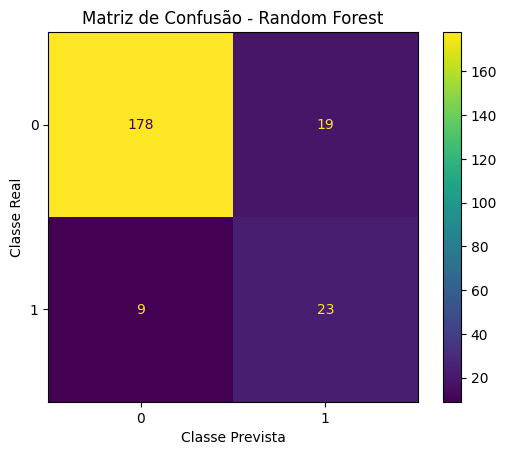

In [217]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.savefig(
    "results/ML/matriz_confusao_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Análise

A matriz de confusão mostra que o modelo Random Forest classificou corretamente **178 observações da classe 0 (Verdadeiros Negativos)** e **23 observações da classe 1 (Verdadeiros Positivos)**.

Além disso, foram observados **19 Falsos Positivos**, indicando uma redução em relação ao modelo Decision Tree, e **9 Falsos Negativos**, mantendo a mesma capacidade de identificação dos casos positivos.

Comparando com o Decision Tree, observa-se um aumento no número de Verdadeiros Negativos e uma redução dos Falsos Positivos, enquanto os Verdadeiros Positivos e os Falsos Negativos permaneceram inalterados. Esses resultados explicam o aumento da métrica Precision observado no Random Forest, tornando o modelo mais confiável ao classificar vinhos como pertencentes à classe positiva.

## Curva ROC (Receiver Operating Characteristic)

A curva ROC (Receiver Operating Characteristic) permite avaliar a capacidade do modelo Random Forest em distinguir corretamente as classes considerando todos os possíveis valores de threshold.

Diferentemente das métricas Accuracy, Precision, Recall e F1-score, que utilizam um threshold fixo de 0,5 para gerar as classificações finais, a curva ROC analisa o comportamento do modelo ao longo de todos os limiares de decisão.

O valor da área sob a curva (ROC AUC) representa a capacidade geral de discriminação do modelo. Quanto mais próximo de 1, melhor é sua capacidade de separar corretamente as classes.

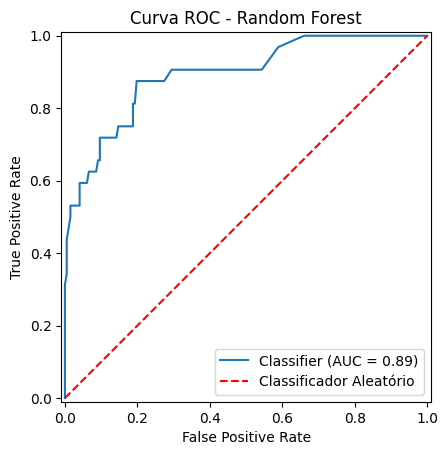

In [218]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red",
    label="Classificador Aleatório"
)

plt.title("Curva ROC - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.savefig(
    "results/ML/curva_roc_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### Análise

A curva ROC mostra que o modelo Random Forest apresentou excelente capacidade de discriminação entre as classes, permanecendo muito acima da linha de referência do classificador aleatório durante praticamente toda a curva.

O valor de **ROC AUC = 0,8928** indica que o modelo possui elevada capacidade para distinguir corretamente observações das classes positiva e negativa considerando todos os possíveis valores de threshold.

Comparando com os modelos anteriores, o Random Forest apresentou o maior valor de ROC AUC, superando tanto a Regressão Logística quanto o Decision Tree, evidenciando uma melhor capacidade geral de separação entre as classes.

## Importância das Variáveis

Diferentemente do Decision Tree, em que é possível visualizar toda a estrutura da árvore, o Random Forest é composto por diversas árvores de decisão, tornando inviável a interpretação individual de cada uma delas.

Uma das principais vantagens desse algoritmo é a possibilidade de calcular a importância de cada variável na construção do modelo.

A importância das variáveis indica o quanto cada atributo contribuiu para reduzir a impureza dos nós durante o treinamento das árvores. Quanto maior o valor de importância, maior foi a contribuição daquela variável para o processo de classificação.

In [205]:
# Importância das variáveis
importancias = modelo_rf.feature_importances_

# Criando um DataFrame
df_importancias = pd.DataFrame({"Variável": X.columns, "Importância": importancias})

# Ordanando da maior para a menor importancia
df_importancias = df_importancias.sort_values(by="Importância", ascending=False)

# Reiniciamos o índice
df_importancias = df_importancias.reset_index(drop=True)

df_importancias

,Variável,Importância
0,alcohol,0.232435
1,volatile acidity,0.140737
2,sulphates,0.138419
3,citric acid,0.100675
4,total sulfur dioxide,0.067614
5,chlorides,0.064971
6,density,0.064301
7,fixed acidity,0.055494
8,pH,0.048195
9,free sulfur dioxide,0.045404


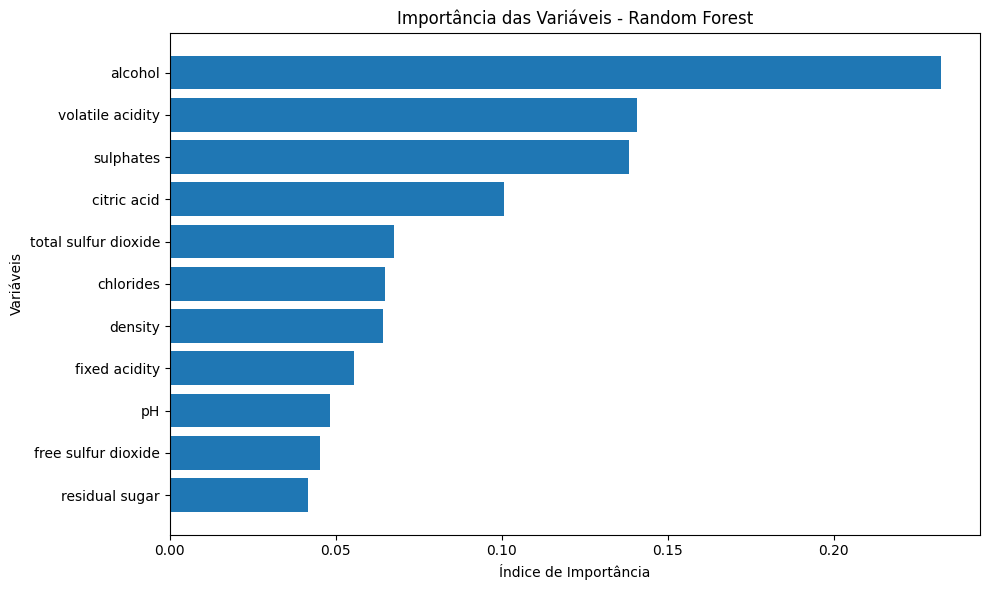

In [206]:
plt.figure(figsize=(10,6))

plt.barh(df_importancias["Variável"], df_importancias["Importância"])

plt.gca().invert_yaxis()

plt.title("Importância das Variáveis - Random Forest")
plt.xlabel("Índice de Importância")
plt.ylabel("Variáveis")

plt.tight_layout()

plt.savefig("feature_importance_random_forest.png", dpi=300, bbox_inches="tight")

plt.show()

### Análise

A análise da importância das variáveis mostra que o atributo **Alcohol** foi o mais relevante para a classificação da qualidade dos vinhos, apresentando o maior índice de importância entre todas as variáveis analisadas.

Em seguida destacam-se **Volatile Acidity** e **Sulphates**, indicando que essas características também exerceram forte influência nas decisões do modelo.

Observa-se ainda que variáveis como **Citric Acid**, **Total Sulfur Dioxide**, **Chlorides** e **Density** contribuíram de forma intermediária para o processo de classificação, enquanto **Residual Sugar**, **Free Sulfur Dioxide** e **pH** apresentaram menor importância relativa.

Os resultados obtidos são consistentes com a análise realizada no modelo Decision Tree, no qual a variável **Alcohol** também foi utilizada como a primeira divisão da árvore, reforçando sua relevância para a classificação da qualidade dos vinhos.

#6.Comparação dos Modelos

Após o desenvolvimento dos três algoritmos de classificação supervisionada, torna-se importante comparar seus desempenhos utilizando as principais métricas de avaliação.

Nesta etapa serão analisados os resultados obtidos pelos modelos Logistic Regression, Decision Tree e Random Forest, considerando as métricas Accuracy, Precision, Recall, F1-score e ROC AUC.

Essa comparação permitirá identificar o modelo com melhor capacidade de classificação para o problema proposto e justificar tecnicamente a escolha do modelo final.

In [207]:
comparacao = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ],
    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf
    ],
    "F1-score": [
        f1_lr,
        f1_dt,
        f1_rf
    ],
    "ROC AUC": [
        auc_lr,
        roc_auc_dt,
        roc_auc_rf
    ]
})

comparacao = comparacao.round(4)

comparacao

,Modelo,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Logistic Regression,0.7817,0.3548,0.6875,0.4681,0.8393
1,Decision Tree,0.8646,0.5111,0.7188,0.5974,0.8035
2,Random Forest,0.8777,0.5476,0.7188,0.6216,0.8928


##6. Análise Comparativa dos Modelos

Após a avaliação dos três algoritmos de classificação, observa-se que cada modelo apresentou características distintas em relação às métricas analisadas.

A Regressão Logística foi utilizada como modelo baseline, apresentando desempenho satisfatório, principalmente em termos de ROC AUC. Entretanto, apresentou os menores valores de Accuracy, Precision e F1-score entre os modelos avaliados.

O Decision Tree apresentou uma melhora significativa em relação à Regressão Logística nas métricas de Accuracy, Precision, Recall e F1-score. Além disso, destacou-se por sua elevada interpretabilidade, permitindo visualizar claramente as regras utilizadas para realizar a classificação.

O Random Forest apresentou o melhor desempenho geral. O modelo obteve os maiores valores de Accuracy, Precision, F1-score e ROC AUC, além de manter o mesmo Recall obtido pelo Decision Tree. Esses resultados indicam que a combinação de múltiplas árvores de decisão proporcionou maior robustez e melhor capacidade de generalização.

## Conclusão Final

Com base na comparação realizada, conclui-se que o **Random Forest** foi o modelo que apresentou o melhor desempenho para o problema de classificação da qualidade dos vinhos.

Embora a Regressão Logística tenha apresentado um bom desempenho como modelo baseline e o Decision Tree tenha oferecido elevada interpretabilidade, o Random Forest destacou-se por alcançar o melhor equilíbrio entre Accuracy, Precision, Recall, F1-score e ROC AUC.

Além do excelente desempenho preditivo, a análise da importância das variáveis permitiu identificar que **Alcohol**, **Volatile Acidity** e **Sulphates** foram os atributos que mais contribuíram para a classificação da qualidade dos vinhos.

Dessa forma, o Random Forest foi selecionado como o modelo mais adequado para este problema, demonstrando elevada capacidade de generalização e robustez na classificação dos dados.

**Implicações para o Processo de Produção**

Os resultados obtidos indicam que variáveis como **Alcohol**, **Volatile Acidity** e **Sulphates** desempenham papel fundamental na classificação da qualidade dos vinhos.

Essas informações podem auxiliar produtores e enólogos no monitoramento do processo produtivo, permitindo identificar quais características físico-químicas merecem maior atenção durante a fabricação.

Além disso, modelos de Machine Learning podem ser utilizados como ferramentas de apoio à tomada de decisão, contribuindo para o controle de qualidade, redução de desperdícios e padronização da produção.

Embora o modelo desenvolvido não substitua a avaliação sensorial realizada por especialistas, ele pode servir como uma ferramenta complementar para prever a qualidade do vinho a partir de suas características laboratoriais.